# CCP4 Electron Density Map Visualization — 14GS

Visualises `14gs.ccp4` (CCP4/MRC format, from PDBe EDS).  
Pocket atom coordinates are overlaid from the CrossDocked2020 pocket PDB.

| Plot | What it shows |
|---|---|
| Map metadata | Cell, grid, statistics |
| Density histogram | Value distribution, σ contour levels |
| 2D orthogonal slices | Three planes through pocket centroid with atom overlay |
| 3D isosurface | Interactive Plotly: density + pocket atoms |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.graph_objects as go
import gemmi
import math
from pathlib import Path

CCP4_FILE  = Path("14gs.ccp4")
POCKET_PDB = Path("../voxbind/dataset/data/crossdocked_pocket10/"
                  "GSTP1_HUMAN_2_210_0/14gs_A_rec_20gs_cbd_lig_tt_min_0_pocket10.pdb")

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

## 1. Load Map and Metadata

In [ ]:
m = gemmi.read_ccp4_map(str(CCP4_FILE))
m.setup(float('nan'))
grid = m.grid

arr  = np.array(grid, dtype=np.float32)   # (nu, nv, nw)
cell = grid.unit_cell
nu, nv, nw = arr.shape

mean  = float(np.nanmean(arr))
sigma = float(np.nanstd(arr))
pct_neg = 100.0 * np.sum(arr < 0) / arr.size

print(f"Grid shape  : {nu} x {nv} x {nw}")
print(f"Space group : {grid.spacegroup.hm}")
print(f"Unit cell   : a={cell.a:.3f}  b={cell.b:.3f}  c={cell.c:.3f} \u00c5")
print(f"              \u03b1={cell.alpha:.2f}  \u03b2={cell.beta:.2f}  \u03b3={cell.gamma:.2f}\u00b0")
print(f"Map mean    : {mean:.4f}")
print(f"Map sigma   : {sigma:.4f}")
print(f"% negative  : {pct_neg:.1f}%  (>50% \u2192 EDS/difference map)")

Grid shape  : 60 x 72 x 50
Space group : C 1 2 1
Unit cell   : a=78.651  b=91.826  c=69.143 Å
              α=90.00  β=98.25  γ=90.00°
Map mean    : 0.0000
Map sigma   : 0.1973
% negative  : 52.8%  (>50% → EDS/difference map)


## 2. Load Pocket Atoms

In [ ]:
st = gemmi.read_structure(str(POCKET_PDB))

pocket_atoms = []  # list of (x, y, z, element)
for model in st:
    for chain in model:
        for res in chain:
            for atom in res:
                pos = atom.pos
                pocket_atoms.append((pos.x, pos.y, pos.z, atom.element.name))

pocket_xyz   = np.array([[a[0], a[1], a[2]] for a in pocket_atoms])  # (N, 3) Angstrom
pocket_elems = [a[3] for a in pocket_atoms]

# Cartesian \u2192 fractional \u2192 grid index
pocket_grid = np.zeros_like(pocket_xyz)
for i, (x, y, z) in enumerate(pocket_xyz):
    frac = cell.fractionalize(gemmi.Position(x, y, z))
    pocket_grid[i] = [frac.x * nu, frac.y * nv, frac.z * nw]

centroid = pocket_grid.mean(axis=0)
ELEM_COLOR = {"C": "gray", "N": "blue", "O": "red", "S": "goldenrod"}

print(f"Pocket atoms    : {len(pocket_atoms)}")
print(f"Centroid (grid) : u={centroid[0]:.1f}  v={centroid[1]:.1f}  w={centroid[2]:.1f}")

Pocket atoms    : 255
Centroid (grid) : u=19.7  v=7.6  w=19.6


## 3. Density Histogram

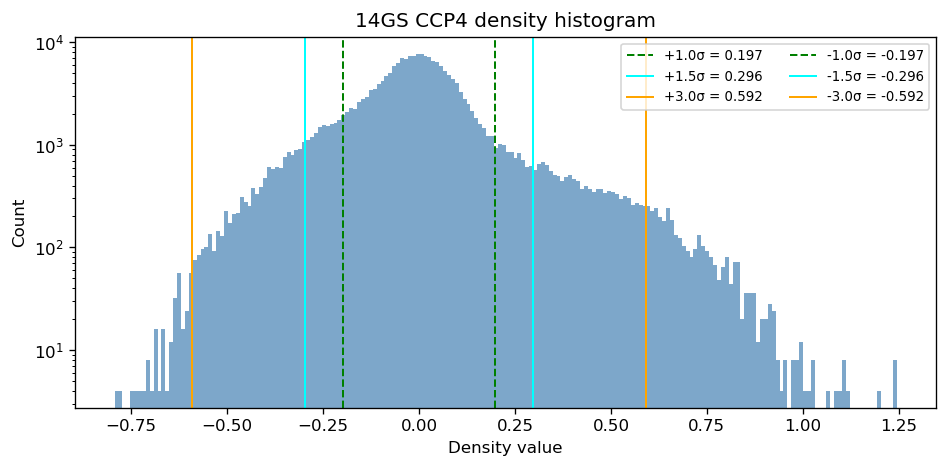

Contour levels:  +1.5σ = 0.2959   +3σ = 0.5919
               −1.5σ = -0.2959   −3σ = -0.5919


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
vals = arr.ravel()
ax.hist(vals, bins=200, color="steelblue", alpha=0.7, edgecolor="none")

for level, color, ls in [
    ( 1.0, "green",  "--"),
    ( 1.5, "cyan",   "-"),
    ( 3.0, "orange", "-"),
    (-1.0, "green",  "--"),
    (-1.5, "cyan",   "-"),
    (-3.0, "orange", "-"),
]:
    v = mean + level * sigma
    ax.axvline(v, color=color, ls=ls, lw=1.2, label=f"{level:+.1f}\u03c3 = {v:.3f}")

ax.set_xlabel("Density value")
ax.set_ylabel("Count")
ax.set_title("14GS CCP4 density histogram")
ax.legend(fontsize=8, ncol=2)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

print(f"Contour levels:  +1.5\u03c3 = {mean + 1.5*sigma:.4f}   +3\u03c3 = {mean + 3*sigma:.4f}")
print(f"               \u22121.5\u03c3 = {mean - 1.5*sigma:.4f}   \u22123\u03c3 = {mean - 3*sigma:.4f}")

## 4. 2D Orthogonal Slices Through Pocket Centroid

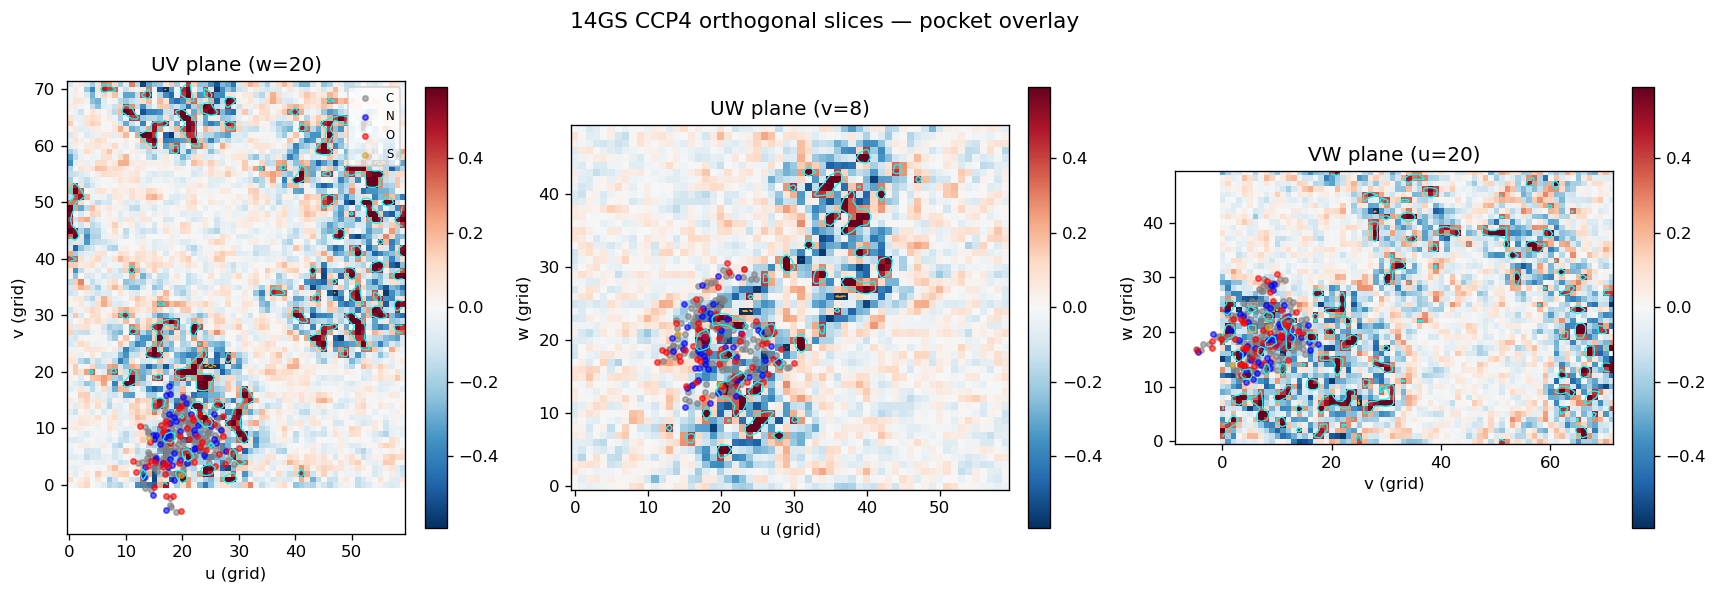

In [ ]:
ci = int(np.clip(round(centroid[0]), 0, nu - 1))
cj = int(np.clip(round(centroid[1]), 0, nv - 1))
ck = int(np.clip(round(centroid[2]), 0, nw - 1))

vmin, vmax = mean - 3 * sigma, mean + 3 * sigma

slice_specs = [
    (f"UV plane (w={ck})", arr[:, :, ck], pocket_grid[:, 0], pocket_grid[:, 1], "u (grid)", "v (grid)"),
    (f"UW plane (v={cj})", arr[:, cj, :], pocket_grid[:, 0], pocket_grid[:, 2], "u (grid)", "w (grid)"),
    (f"VW plane (u={ci})", arr[ci, :, :], pocket_grid[:, 1], pocket_grid[:, 2], "v (grid)", "w (grid)"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, slc, px, py, xl, yl) in zip(axes, slice_specs):
    im = ax.imshow(slc.T, origin="lower", cmap="RdBu_r",
                   vmin=vmin, vmax=vmax, aspect="equal")
    ax.contour(slc.T, levels=[mean + 1.5 * sigma],
               colors=["cyan"],   linewidths=0.8)
    ax.contour(slc.T, levels=[mean - 3.0 * sigma],
               colors=["orange"], linewidths=0.8, linestyles="dashed")

    for elem in sorted(set(pocket_elems)):
        mask = np.array([e == elem for e in pocket_elems])
        ax.scatter(np.array(px)[mask], np.array(py)[mask],
                   c=ELEM_COLOR.get(elem, "purple"), s=10,
                   alpha=0.6, label=elem)

    ax.set_title(title)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes[0].legend(fontsize=7, loc="upper right")
plt.suptitle("14GS CCP4 orthogonal slices \u2014 pocket overlay", fontsize=13)
plt.tight_layout()
plt.show()

## 5. 3D Isosurface + Pocket Atoms (Plotly)

A sub-box around the pocket centroid is extracted and rendered as two isosurfaces:  
**blue** = +1.5\u03c3 (positive density),  **red** = \u22123\u03c3 (negative density, e.g. missing atoms).

In [ ]:
# Sub-box around pocket centroid
R = 18
i0, i1 = max(0, ci - R), min(nu, ci + R)
j0, j1 = max(0, cj - R), min(nv, cj + R)
k0, k1 = max(0, ck - R), min(nw, ck + R)
sub = arr[i0:i1, j0:j1, k0:k1]

# Grid indices \u2192 Cartesian \u00c5 (monoclinic: x = a*fa + c*cos(\u03b2)*fc)
beta_rad = math.radians(cell.beta)
a_len, b_len, c_len = cell.a, cell.b, cell.c

ii = np.arange(i0, i1, dtype=float) / nu
jj = np.arange(j0, j1, dtype=float) / nv
kk = np.arange(k0, k1, dtype=float) / nw
Fi, Fj, Fk = np.meshgrid(ii, jj, kk, indexing="ij")

Xc = a_len * Fi + c_len * math.cos(beta_rad) * Fk
Yc = b_len * Fj
Zc = c_len * math.sin(beta_rad) * Fk

pos_thresh = mean + 1.5 * sigma
neg_thresh = mean - 3.0 * sigma

traces = []

traces.append(go.Isosurface(
    x=Xc.ravel(), y=Yc.ravel(), z=Zc.ravel(),
    value=sub.ravel(),
    isomin=pos_thresh, isomax=pos_thresh,
    surface_count=1,
    colorscale=[[0, "blue"], [1, "blue"]],
    showscale=False, opacity=0.35,
    name="+1.5\u03c3",
    caps=dict(x_show=False, y_show=False, z_show=False),
))

traces.append(go.Isosurface(
    x=Xc.ravel(), y=Yc.ravel(), z=Zc.ravel(),
    value=sub.ravel(),
    isomin=neg_thresh, isomax=neg_thresh,
    surface_count=1,
    colorscale=[[0, "red"], [1, "red"]],
    showscale=False, opacity=0.25,
    name="\u22123\u03c3",
    caps=dict(x_show=False, y_show=False, z_show=False),
))

for elem in sorted(set(pocket_elems)):
    mask = np.array([e == elem for e in pocket_elems])
    xyz  = pocket_xyz[mask]
    traces.append(go.Scatter3d(
        x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
        mode="markers",
        marker=dict(size=3, color=ELEM_COLOR.get(elem, "purple"), opacity=0.8),
        name=f"pocket {elem}",
    ))

fig = go.Figure(traces)
fig.update_layout(
    title="14GS CCP4 \u2014 3D isosurface + pocket atoms",
    scene=dict(
        xaxis_title="X (\u00c5)",
        yaxis_title="Y (\u00c5)",
        zaxis_title="Z (\u00c5)",
        aspectmode="data",
    ),
    width=800, height=650,
)
fig.show()

## 6. Image Resolution

The map grid directly determines the **sampling resolution** (Nyquist limit).  
The **crystallographic resolution** (from deposited structure factors) sets the true information limit.

In [ ]:
# ── Voxel size along each crystallographic axis ───────────────────────────
vox_a = cell.a / nu   # Å / voxel along a
vox_b = cell.b / nv   # Å / voxel along b
vox_c = cell.c / nw   # Å / voxel along c

# Nyquist limit: finest detail the grid can represent = 2 × voxel size
nyq_a = 2 * vox_a
nyq_b = 2 * vox_b
nyq_c = 2 * vox_c

# Average voxel size (isotropic approximation)
vox_mean = (vox_a + vox_b + vox_c) / 3

print("=== CCP4 Map Resolution ===")
print(f"Grid           : {nu} × {nv} × {nw}")
print(f"Unit cell      : a={cell.a:.3f}  b={cell.b:.3f}  c={cell.c:.3f}  (Å)")
print()
print(f"Voxel size     : {vox_a:.3f} × {vox_b:.3f} × {vox_c:.3f}  Å/voxel  (a × b × c)")
print(f"               = {vox_mean:.3f} Å  (mean)")
print()
print(f"Nyquist limit  : {nyq_a:.3f} × {nyq_b:.3f} × {nyq_c:.3f}  Å  (2 × voxel)")
print(f"               = {2*vox_mean:.3f} Å  (mean) — finest resolvable feature")
print()
print(f"Crystallographic resolution (from SF file): 2.80 Å")
print(f"  → Nyquist ({2*vox_mean:.2f} Å) < d_min (2.80 Å): grid is adequately sampled")

=== CCP4 Map Resolution ===
Grid           : 60 × 72 × 50
Unit cell      : a=78.651  b=91.826  c=69.143  (Å)

Voxel size     : 1.311 × 1.275 × 1.383  Å/voxel  (a × b × c)
               = 1.323 Å  (mean)

Nyquist limit  : 2.622 × 2.551 × 2.766  Å  (2 × voxel)
               = 2.646 Å  (mean) — finest resolvable feature

Crystallographic resolution (from SF file): 2.80 Å
  → Nyquist (2.65 Å) < d_min (2.80 Å): grid is adequately sampled


## 7. Full-Map Density Scatter (Plotly)

Every voxel with |density| ≥ 1σ is plotted as a point in Cartesian Å space,\n
coloured by its raw density value (RdBu: blue = positive, red = negative).

In [ ]:
beta_rad = math.radians(cell.beta)
a_len, b_len, c_len = cell.a, cell.b, cell.c

# ── Full Cartesian grid for all 60×72×50 voxels ───────────────────────────
ii = np.arange(nu, dtype=np.float32) / nu
jj = np.arange(nv, dtype=np.float32) / nv
kk = np.arange(nw, dtype=np.float32) / nw
Fi, Fj, Fk = np.meshgrid(ii, jj, kk, indexing="ij")

Xc_all = (a_len * Fi + c_len * math.cos(beta_rad) * Fk).ravel()
Yc_all = (b_len * Fj).ravel()
Zc_all = (c_len * math.sin(beta_rad) * Fk).ravel()
vals   = arr.ravel()

# ── Keep only voxels with |density| >= 1σ ────────────────────────────────
threshold = 1.0 * sigma
mask = np.abs(vals) >= threshold

Xc = Xc_all[mask]
Yc = Yc_all[mask]
Zc = Zc_all[mask]
v  = vals[mask]

print(f"Total voxels          : {vals.size:,}  ({nu}\u00d7{nv}\u00d7{nw})")
print(f"Plotted (|\u03c1| \u2265 1\u03c3)     : {mask.sum():,}")
print(f"  positive (\u2265+1\u03c3)    : {(v > 0).sum():,}")
print(f"  negative (\u2264-1\u03c3)    : {(v < 0).sum():,}")

# ── Scatter3d coloured by density value ───────────────────────────────────
clim = 2.0 * sigma   # symmetric colour limits

fig = go.Figure(go.Scatter3d(
    x=Xc, y=Yc, z=Zc,
    mode="markers",
    marker=dict(
        size=2,
        color=v,
        colorscale="RdBu",
        reversescale=True,          # blue = positive, red = negative
        cmin=-clim,
        cmax= clim,
        opacity=0.6,
        colorbar=dict(
            title="\u03c1 (density)",
            thickness=14,
            len=0.65,
        ),
    ),
    hovertemplate="x=%{x:.1f} \u00c5<br>y=%{y:.1f} \u00c5<br>z=%{z:.1f} \u00c5<br>\u03c1=%{marker.color:.4f}<extra></extra>",
))

fig.update_layout(
    title=f"14GS CCP4 — density scatter (|\u03c1| \u2265 1\u03c3, {mask.sum():,} points)",
    scene=dict(
        xaxis_title="X (\u00c5)",
        yaxis_title="Y (\u00c5)",
        zaxis_title="Z (\u00c5)",
        aspectmode="data",
        bgcolor="rgb(15,15,15)",
    ),
    paper_bgcolor="rgb(25,25,25)",
    font_color="white",
    width=900, height=700,
)
fig.show()

In [ ]:
iso_kw

{'x': array([ 0.        , -0.19843021, -0.39686042, ..., 68.01393   ,
        67.8155    , 67.617065  ], shape=(216000,), dtype=float32),
 'y': array([ 0.     ,  0.     ,  0.     , ..., 90.55064, 90.55064, 90.55064],
       shape=(216000,), dtype=float32),
 'z': array([ 0.       ,  1.3685493,  2.7370987, ..., 64.321815 , 65.69037  ,
        67.05892  ], shape=(216000,), dtype=float32),
 'caps': {'x_show': False, 'y_show': False, 'z_show': False},
 'surface_count': 4}